<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Breastcancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3851/1538277335.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


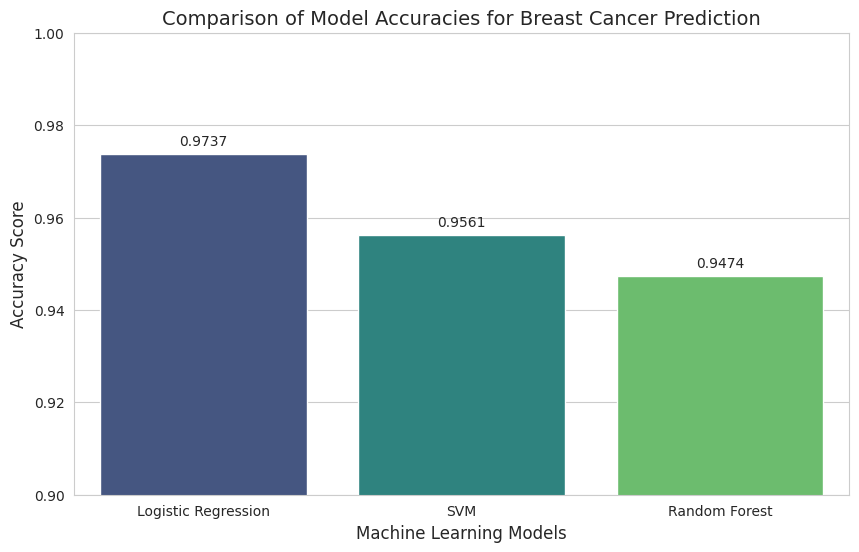

In [2]:
import numpy as np
import pandas as pd
import sklearn.datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Load the dataset
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)
data_frame['label'] = breast_cancer_dataset.target

# 2. Separate Features and Target
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

# 3. Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Model Training ---

# A. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, Y_train)
lr_acc = accuracy_score(Y_test, lr_model.predict(X_test_scaled))

# B. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train)
rf_acc = accuracy_score(Y_test, rf_model.predict(X_test))

# C. SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, Y_train)
svm_acc = accuracy_score(Y_test, svm_model.predict(X_test_scaled))

# --- 6. Results and Visualization ---

# Create a DataFrame for results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [lr_acc, rf_acc, svm_acc]
})

# Sorting results for better visualization
results = results.sort_values(by='Accuracy', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plot = sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')

# Adding labels and title
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Comparison of Model Accuracies for Breast Cancer Prediction', fontsize=14)
plt.ylim(0.9, 1.0) # Zooming in to see differences between 90% and 100%

# Adding the values on top of bars
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()